<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/090_weight_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np

In [15]:
import matplotlib.pyplot as plt

In [16]:
np.random.seed(42)

In [17]:
def relu(z):
  return np.maximum(0,z)

In [18]:
def tanh(z):
  return np.tanh(z)

In [19]:
def forward(W_scale, activation, n_sample=1000, n_unit=500, layer=10):
  x = np.random.normal(0, 1, (n_sample, n_unit))
  std = [x.std()]
  for _ in range(layer):
    w = np.random.normal(0, W_scale, (n_unit, n_unit))
    z = x @ w
    x = activation(z)
    std.append(x.std())
  return std

In [20]:
std_small=forward(0.01,tanh)

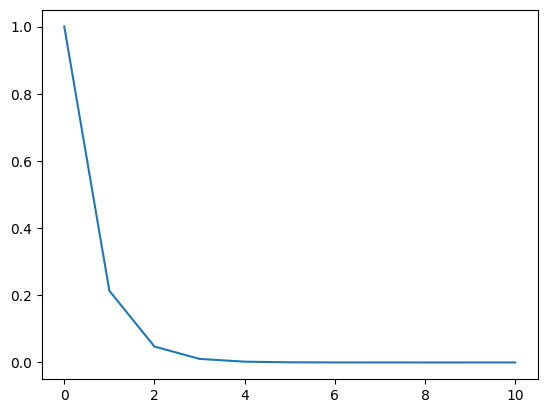

In [23]:
plt.plot(std_small)

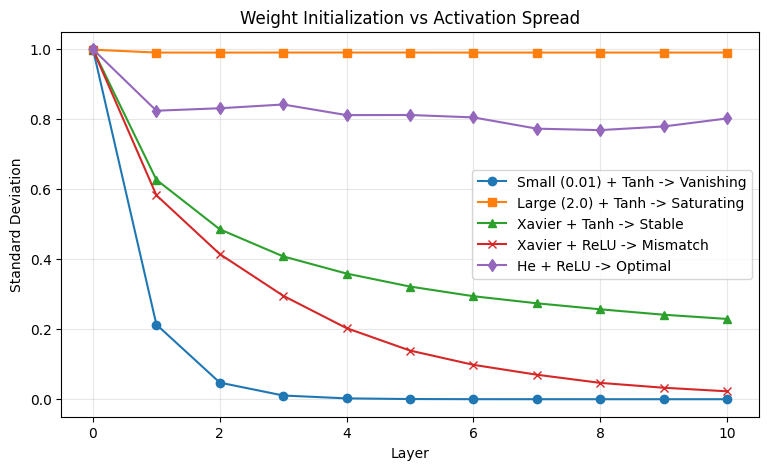

In [24]:

std_large = forward(2.0, tanh)
xavier_std = np.sqrt(2.0 / (500 + 500))
std_xavier_tanh = forward(xavier_std, tanh)
std_xavier_relu = forward(xavier_std, relu)
he_std = np.sqrt(2.0 / 500)
std_he_relu = forward(he_std, relu)

# Comparison Plot
plt.figure(figsize=(9, 5))
plt.plot(std_small, marker="o", label="Small (0.01) + Tanh -> Vanishing")
plt.plot(std_large, marker="s", label="Large (2.0) + Tanh -> Saturating")
plt.plot(std_xavier_tanh, marker="^", label="Xavier + Tanh -> Stable")
plt.plot(std_xavier_relu, marker="x", label="Xavier + ReLU -> Mismatch")
plt.plot(std_he_relu, marker="d", label="He + ReLU -> Optimal")

plt.xlabel("Layer")
plt.ylabel("Standard Deviation")
plt.title("Weight Initialization vs Activation Spread")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()